In [10]:
!pip install --quiet pmdarima

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
from pmdarima import auto_arima
from pmdarima.model_selection import RollingForecastCV
from pmdarima.model_selection import cross_val_score
from pmdarima.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from scipy.stats import norm

In [5]:
# Read dataframe
df = pd.read_csv('../data/validaciones.csv', index_col='Fecha', parse_dates=['Fecha'])
df.head(3)

,(10000) Portal 20 de Julio,(10001) Country Sur,(10002) Av. Primero de Mayo,(10003) Ciudad Jardín,(10004) Policarpa,(10010) San Bernardo,(10005) Bicentenario,(10006) SAN VICTORINO - NEOS CENTRO,(10007) Las Nieves,(10008) San Diego,Feriado,Dia_semana,Operativo
Fecha,,,,,,,,,,,,,
2025-10-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This dataframe has 15 minutes intervals covering 24 hours of data for each day, but there are about 4 hours a day with NaN values due to the non-operational window of Transmilenio. So, I'm going to simply group data by day in order to avoid issues with the ARIMA-SARIMA models.

In [6]:
# Group by daily frequency
df_a = df.groupby(pd.Grouper(freq='D'))[df.columns[0:10]].sum()
print(df_a.shape)
df_a.head()

(61, 10)


,(10000) Portal 20 de Julio,(10001) Country Sur,(10002) Av. Primero de Mayo,(10003) Ciudad Jardín,(10004) Policarpa,(10010) San Bernardo,(10005) Bicentenario,(10006) SAN VICTORINO - NEOS CENTRO,(10007) Las Nieves,(10008) San Diego
Fecha,,,,,,,,,,
2025-10-01,42105.0,13591.0,20157.0,3461.0,3789.0,7054.0,5475.0,22966.0,13435.0,6248.0
2025-10-02,41250.0,13412.0,19942.0,3387.0,3677.0,6746.0,5958.0,18773.0,11981.0,5819.0
2025-10-03,41474.0,13484.0,20215.0,3366.0,3730.0,6475.0,5164.0,20013.0,12852.0,5814.0
2025-10-04,29337.0,10121.0,14884.0,2564.0,3332.0,4293.0,3488.0,21401.0,10551.0,4132.0
2025-10-05,17008.0,5647.0,6961.0,1349.0,1658.0,2611.0,1687.0,10714.0,3317.0,2219.0


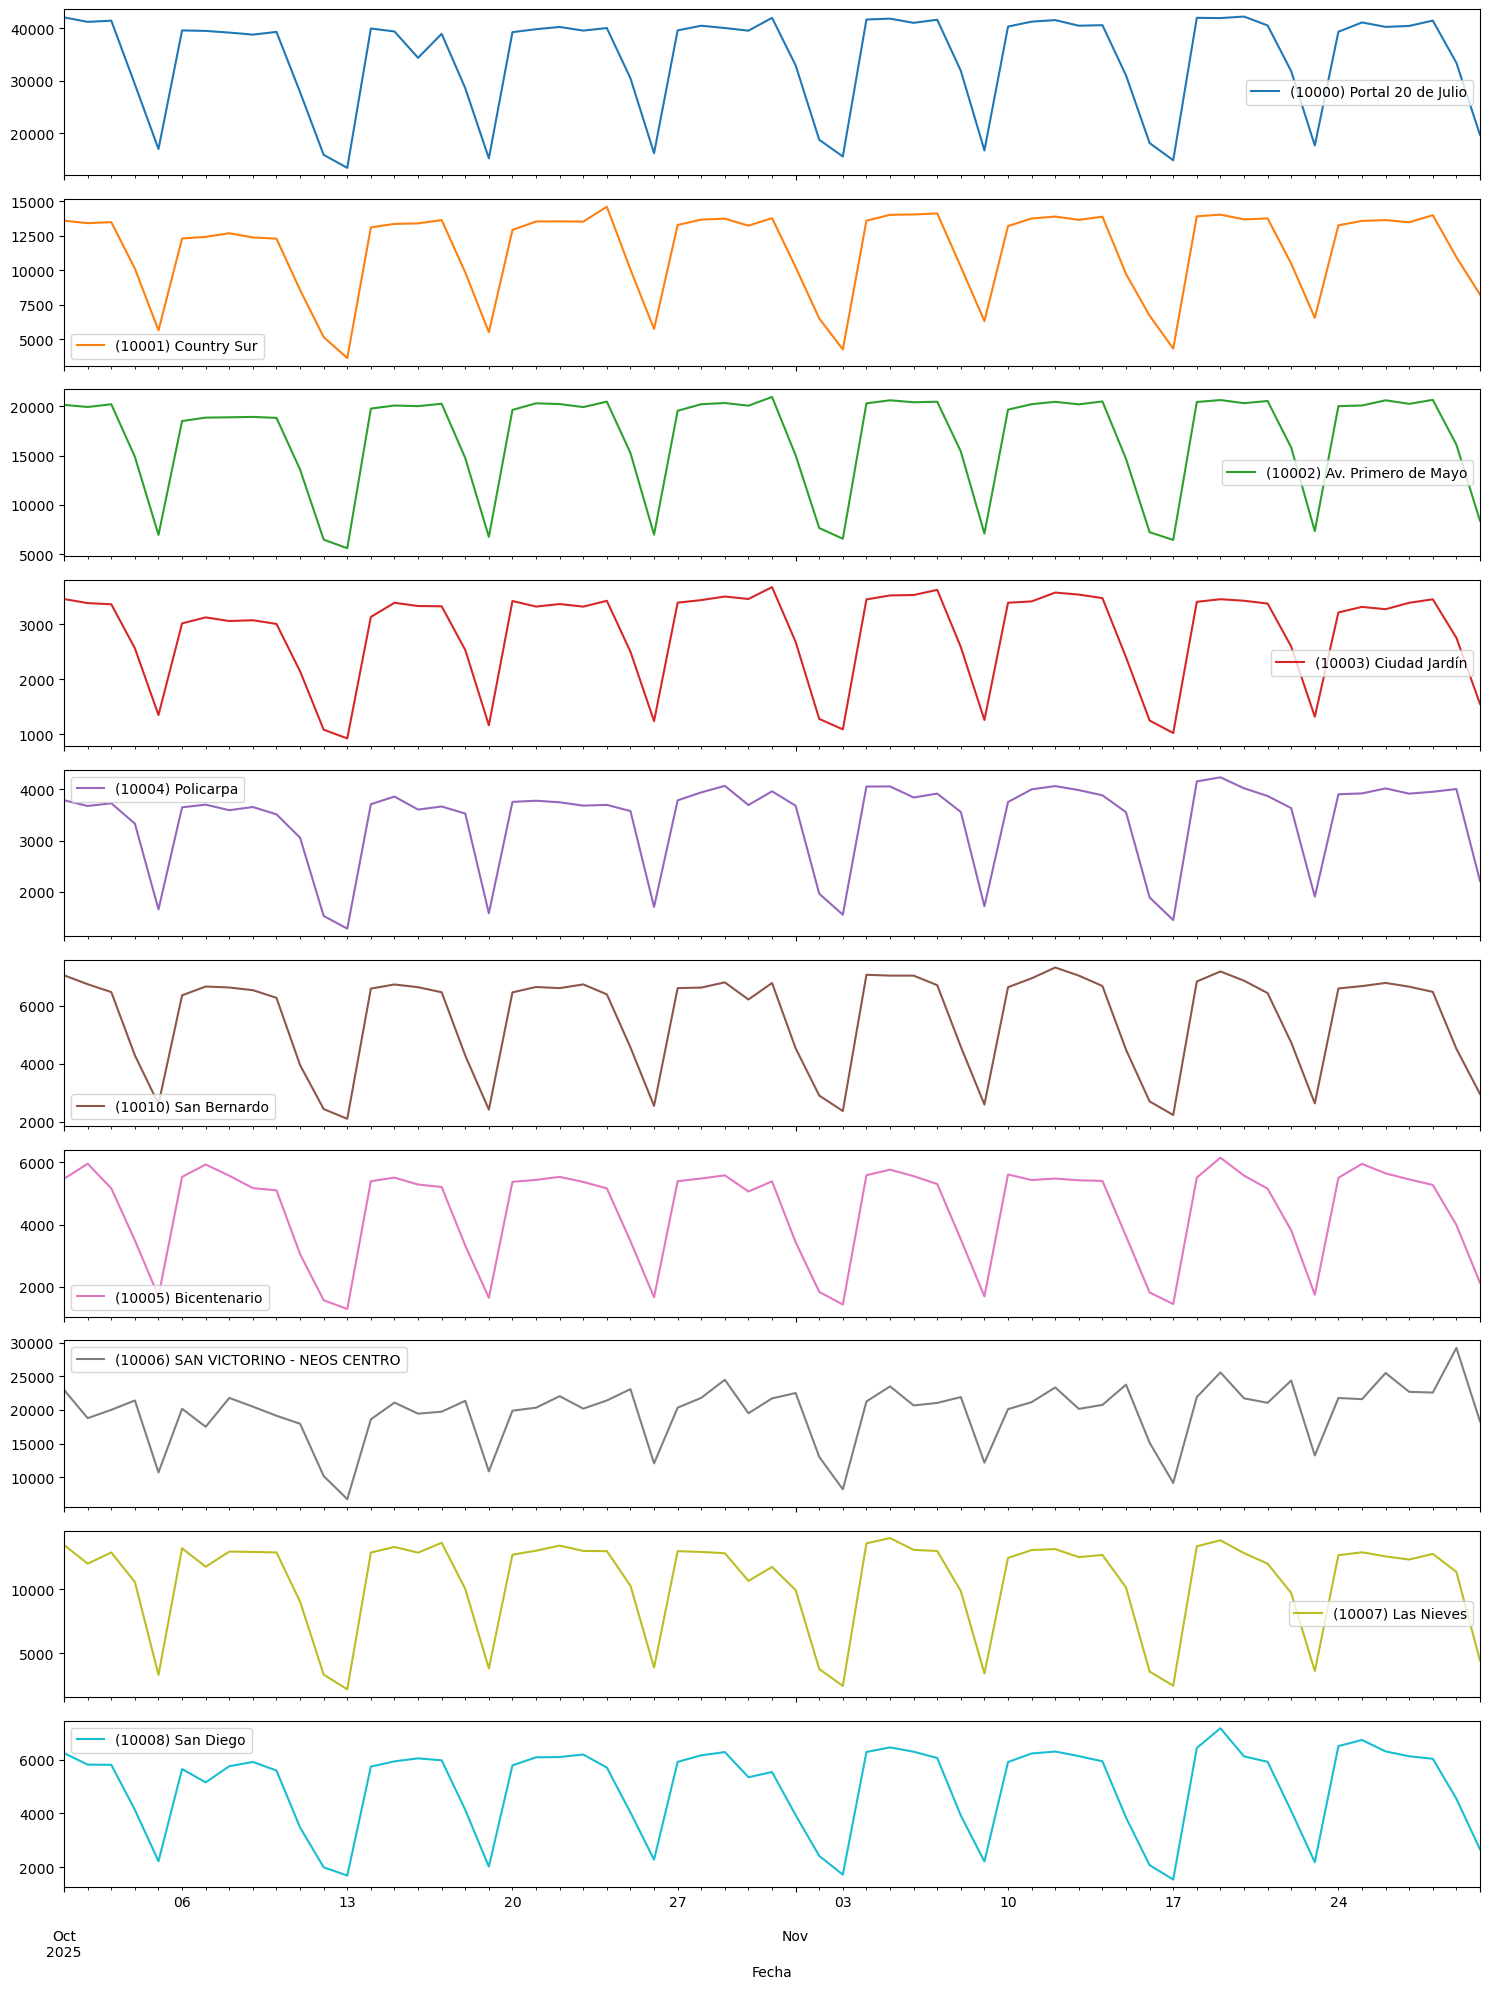

In [7]:
# Entries (validations) per station in the trunk line Carrera 10
df_a.iloc[:, 0:10].plot(subplots=True, figsize=(15, 20), layout=(10, 1))
plt.tight_layout()
plt.show()

In [11]:
# Define function for the auto_arima model
def training_auto_arima(df, n_splits): # df must be the training set, defined when separating the holdout set
    results = []
    for col in df.columns:
        # Train-test split for time series cross validation
        tscv = TimeSeriesSplit(n_splits=n_splits)
        split_num = 0
        for train_index, test_index in tscv.split(df[col]):
            split_num += 1
            train, test = df[col].iloc[train_index], df[col].iloc[test_index]
            arima_model = auto_arima(train, seasonal=False)
            order = getattr(arima_model, 'order', None) or getattr(arima_model, 'order_', None)
            results.append({
                'column': col,
                'split': split_num,
                'train_start': train.index[0],
                'train_end': train.index[-1],
                'test_start': test.index[0],
                'test_end': test.index[-1],
                'size_train': len(train),
                'size_test': len(test),
                'order': order
            })
    results = pd.DataFrame(results)

    return results


In [12]:
# Holdout set is 15% of the whole dataset
train_set, holdout_set = train_test_split(df_a, train_size=0.85)
print(train_set.shape)
print(holdout_set.shape)

(51, 10)
(10, 10)


In [13]:
results = training_auto_arima(train_set, n_splits=7)
results

,column,split,train_start,train_end,test_start,test_end,size_train,size_test,order
0,(10000) Portal 20 de Julio,1,2025-10-01,2025-10-09,2025-10-10,2025-10-15,9,6,"(0, 0, 0)"
1,(10000) Portal 20 de Julio,2,2025-10-01,2025-10-15,2025-10-16,2025-10-21,15,6,"(2, 0, 0)"
2,(10000) Portal 20 de Julio,3,2025-10-01,2025-10-21,2025-10-22,2025-10-27,21,6,"(1, 0, 2)"
3,(10000) Portal 20 de Julio,4,2025-10-01,2025-10-27,2025-10-28,2025-11-02,27,6,"(1, 0, 2)"
4,(10000) Portal 20 de Julio,5,2025-10-01,2025-11-02,2025-11-03,2025-11-08,33,6,"(1, 0, 2)"
...,...,...,...,...,...,...,...,...,...
65,(10008) San Diego,3,2025-10-01,2025-10-21,2025-10-22,2025-10-27,21,6,"(4, 0, 0)"
66,(10008) San Diego,4,2025-10-01,2025-10-27,2025-10-28,2025-11-02,27,6,"(4, 0, 0)"
67,(10008) San Diego,5,2025-10-01,2025-11-02,2025-11-03,2025-11-08,33,6,"(5, 0, 0)"
68,(10008) San Diego,6,2025-10-01,2025-11-08,2025-11-09,2025-11-14,39,6,"(5, 0, 0)"


In [14]:
orders = results.groupby('column')['order'].unique().to_frame()
orders

,order
column,
(10000) Portal 20 de Julio,"[(0, 0, 0), (2, 0, 0), (1, 0, 2)]"
(10001) Country Sur,"[(0, 0, 0), (2, 0, 0), (0, 0, 1)]"
(10002) Av. Primero de Mayo,"[(0, 0, 0), (0, 0, 1), (1, 0, 2), (2, 0, 0)]"
(10003) Ciudad Jardín,"[(0, 0, 0), (2, 0, 0), (2, 0, 2), (0, 0, 1)]"
(10004) Policarpa,"[(0, 0, 0), (0, 0, 1), (2, 0, 0)]"
(10005) Bicentenario,"[(0, 0, 0), (2, 0, 0), (4, 0, 2), (5, 0, 0)]"
(10006) SAN VICTORINO - NEOS CENTRO,"[(0, 0, 0)]"
(10007) Las Nieves,"[(0, 0, 0), (1, 0, 2), (2, 0, 0), (5, 0, 0)]"
(10008) San Diego,"[(0, 0, 0), (3, 0, 0), (4, 0, 0), (5, 0, 0)]"


In [15]:
# Do the cross-validation: 
# For each order in each station, fit the arima for each split and then take the means for the relevant metrics
def arima_cv(scoring='mean_absolute_error'):
    models = []
    problematic_orders = []

    for idx, row in orders.iterrows():
    
        cv = RollingForecastCV(h=6, step = 6, initial=9)

        for order in row.iloc[0]:
            model = pm.ARIMA(order=order, suppress_warnings=False)

            # Capture warnings during fit
            with warnings.catch_warnings(record=True) as w:
                warnings.simplefilter("always")
            
                try:
                    model_cv_scores = cross_val_score(
                        model, train_set[[idx]],
                        scoring=scoring,                # Options: mean_absolute_error, mean_squared_error, smape
                        cv=cv, error_score='raise'
                    )
                    model_av_error = np.average(model_cv_scores)
                    models.append({
                        'station': idx,
                        'order': order,
                        scoring: model_av_error
                    })
                except Exception as e:
                    print(f"Error con estación {idx}, orden {order}: {e}")
                    continue

                # Check for warnings
                for warn in w:
                    if issubclass(warn.category, ConvergenceWarning) or "Non-stationary" in str(warn.message):
                        problematic_orders.append({
                            'station': idx,
                            'order': order,
                            'warning': str(warn.message)
                        })

            #model_cv_scores = cross_val_score(model, train_set[[idx]], scoring='mean_absolute_error', cv=cv, error_score='raise')
            #model_av_error = np.average(model_cv_scores)
            #models.append({
            #    'station': idx,
            #    'order': order,
            #    'error': model_av_error    
            #})
    models = pd.DataFrame(models)
    problematic_orders = pd.DataFrame(problematic_orders)
    
    return models, problematic_orders

Errors:
1. UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
2. ConvergenceWarning: Maximum Likelihood optimization failed to converge.

In [16]:
models_mae, problem_orders_mae = arima_cv('mean_absolute_error')
models_mse, problem_orders_mse = arima_cv('mean_squared_error')
models_smape, problem_orders_smape = arima_cv('smape')

In [17]:
models_ = models_mae.merge(models_mse, on=['station','order'], how='outer')
models = models_.merge(models_smape, on=['station','order'], how='outer')
models

,station,order,mean_absolute_error,mean_squared_error,smape
0,(10000) Portal 20 de Julio,"(0, 0, 0)",8482.587036,1.037023e+08,28.001805
1,(10000) Portal 20 de Julio,"(1, 0, 2)",7864.852417,9.823509e+07,26.225000
2,(10000) Portal 20 de Julio,"(2, 0, 0)",8194.553022,9.554090e+07,27.274512
3,(10001) Country Sur,"(0, 0, 0)",3010.606104,1.219172e+07,29.771453
4,(10001) Country Sur,"(0, 0, 1)",3047.215781,1.219548e+07,30.205987
5,(10001) Country Sur,"(2, 0, 0)",2873.557649,1.119673e+07,28.699739
6,(10002) Av. Primero de Mayo,"(0, 0, 0)",4692.693136,3.071367e+07,32.326264
7,(10002) Av. Primero de Mayo,"(0, 0, 1)",4785.491346,2.903971e+07,33.155213
8,(10002) Av. Primero de Mayo,"(1, 0, 2)",4426.239464,2.841898e+07,30.856132
9,(10002) Av. Primero de Mayo,"(2, 0, 0)",4517.187017,2.863416e+07,31.453619


In [18]:
min_error = models.groupby('station')['smape'].min()
best_models = {}
for index, value in min_error.items():
    best_models[index]=models[(models.station==index)&(models.smape==value)]['order'].iloc[0]
best_models

{'(10000) Portal 20 de Julio': (1, 0, 2),
 '(10001) Country Sur': (2, 0, 0),
 '(10002) Av. Primero de Mayo': (1, 0, 2),
 '(10003) Ciudad Jardín': (2, 0, 0),
 '(10004) Policarpa': (0, 0, 1),
 '(10005) Bicentenario': (4, 0, 2),
 '(10006) SAN VICTORINO - NEOS CENTRO': (0, 0, 0),
 '(10007) Las Nieves': (1, 0, 2),
 '(10008) San Diego': (5, 0, 0),
 '(10010) San Bernardo': (5, 0, 0)}

In [78]:
# Predict on the best models
def predictions(best_models, train_set, holdout_set):
    predictions = {}
    residuals = {}
    for key, value in best_models.items():
        best_order = value
        best_model = pm.ARIMA(order=best_order)
        best_model.fit(train_set[key])          # fits model with all the training data
    
        # Predictions for the next 10 steps
        preds = best_model.predict(n_periods=holdout_set.shape[0])
        predictions[key] = preds

        resids = best_model.resid()
        residuals[key] = resids
    return predictions, residuals

In [75]:
# Plot predictions against original series:
def plot_predictions(predictions, df_a, holdout_set):
    fig, axes = plt.subplots(10, 1, figsize=(15, 30))  # 10 lines, 1 column
    for i, (key,value) in enumerate(predictions.items()):
        x_axis = np.arange(df_a.shape[0])
        n_test = holdout_set.shape[0]

        axes[i].plot(x_axis, df_a[key], alpha=0.75, c='b', label='real series - training set')
        axes[i].plot(x_axis[-n_test:], holdout_set[key], alpha=1, c='g', label='real series - holdout set')
        axes[i].plot(x_axis[-n_test:], value, alpha=0.75, c='r', label='forecast')
        axes[i].set_title("Cross-validated forecast for " + key)
        axes[i].legend(loc='lower left')

    plt.tight_layout()
    plt.show()

In [79]:
predictions, residuals = predictions(best_models, train_set, holdout_set)

c:\Users\aestr\anaconda3\envs\transmilenio_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\aestr\anaconda3\envs\transmilenio_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\aestr\anaconda3\envs\transmilenio_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\aestr\anaconda3\envs\transmilenio_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as 

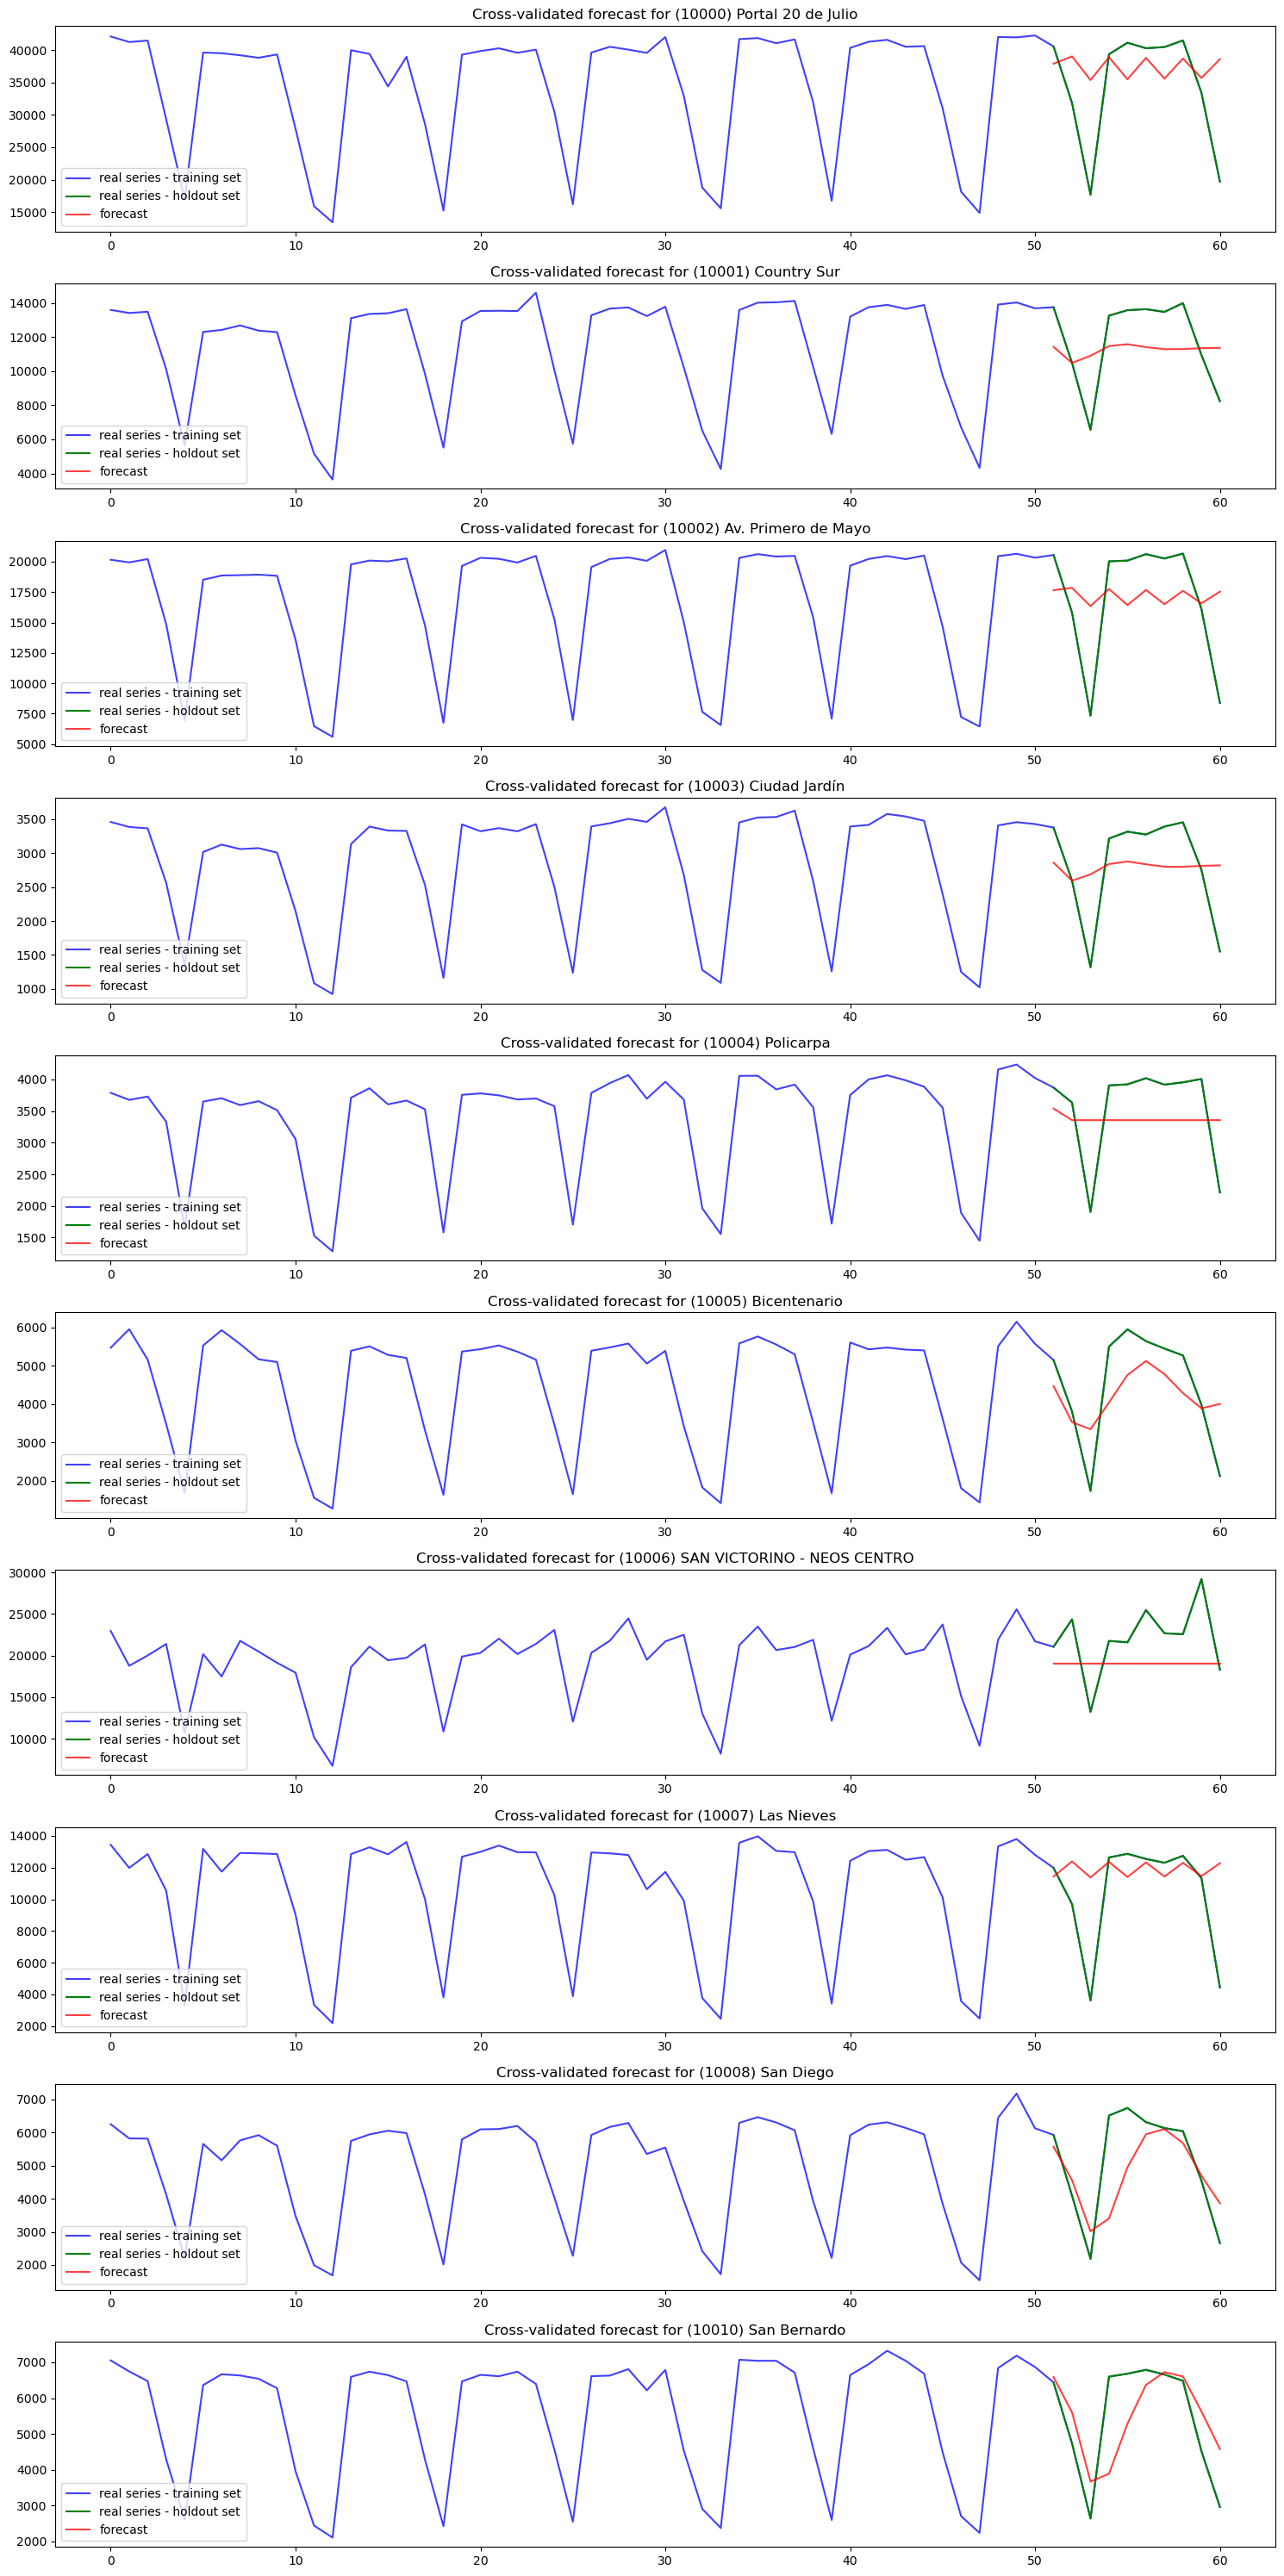

In [77]:
plot_predictions(predictions, df_a, holdout_set)

In [122]:
# Plot the residuals
def plot_residuals(residuals):
    fig, axes = plt.subplots(10, 3, figsize=(15, 30))
    fig.tight_layout(pad=4.0)

    for i, (key,resids) in enumerate(residuals.items()):
        # --- Columna 1: Scatterplot ---
        axes[i, 0].scatter(range(len(resids)), resids, alpha=0.7)
        axes[i, 0].set_title(f"{key} - Residuos")
        axes[i, 0].set_xlabel("Índice temporal")
        axes[i, 0].set_ylabel("Error")

        # --- Columna 2: Histograma con curva normal ---
        sns.histplot(resids, kde=True, ax=axes[i, 1], color="skyblue", stat="density")
        mu, sigma = np.mean(resids), np.std(resids)
        x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
        axes[i, 1].plot(x, norm.pdf(x, mu, sigma), 'r', lw=0.75)
        axes[i, 1].set_title(f"{key} - Histograma residuos")

        # --- Columna 3: QQ plot ---
        sm.qqplot(resids, line='45', ax=axes[i, 2], fit=True)
        axes[i, 2].set_title(f"{key} - QQ Plot")

    plt.show()


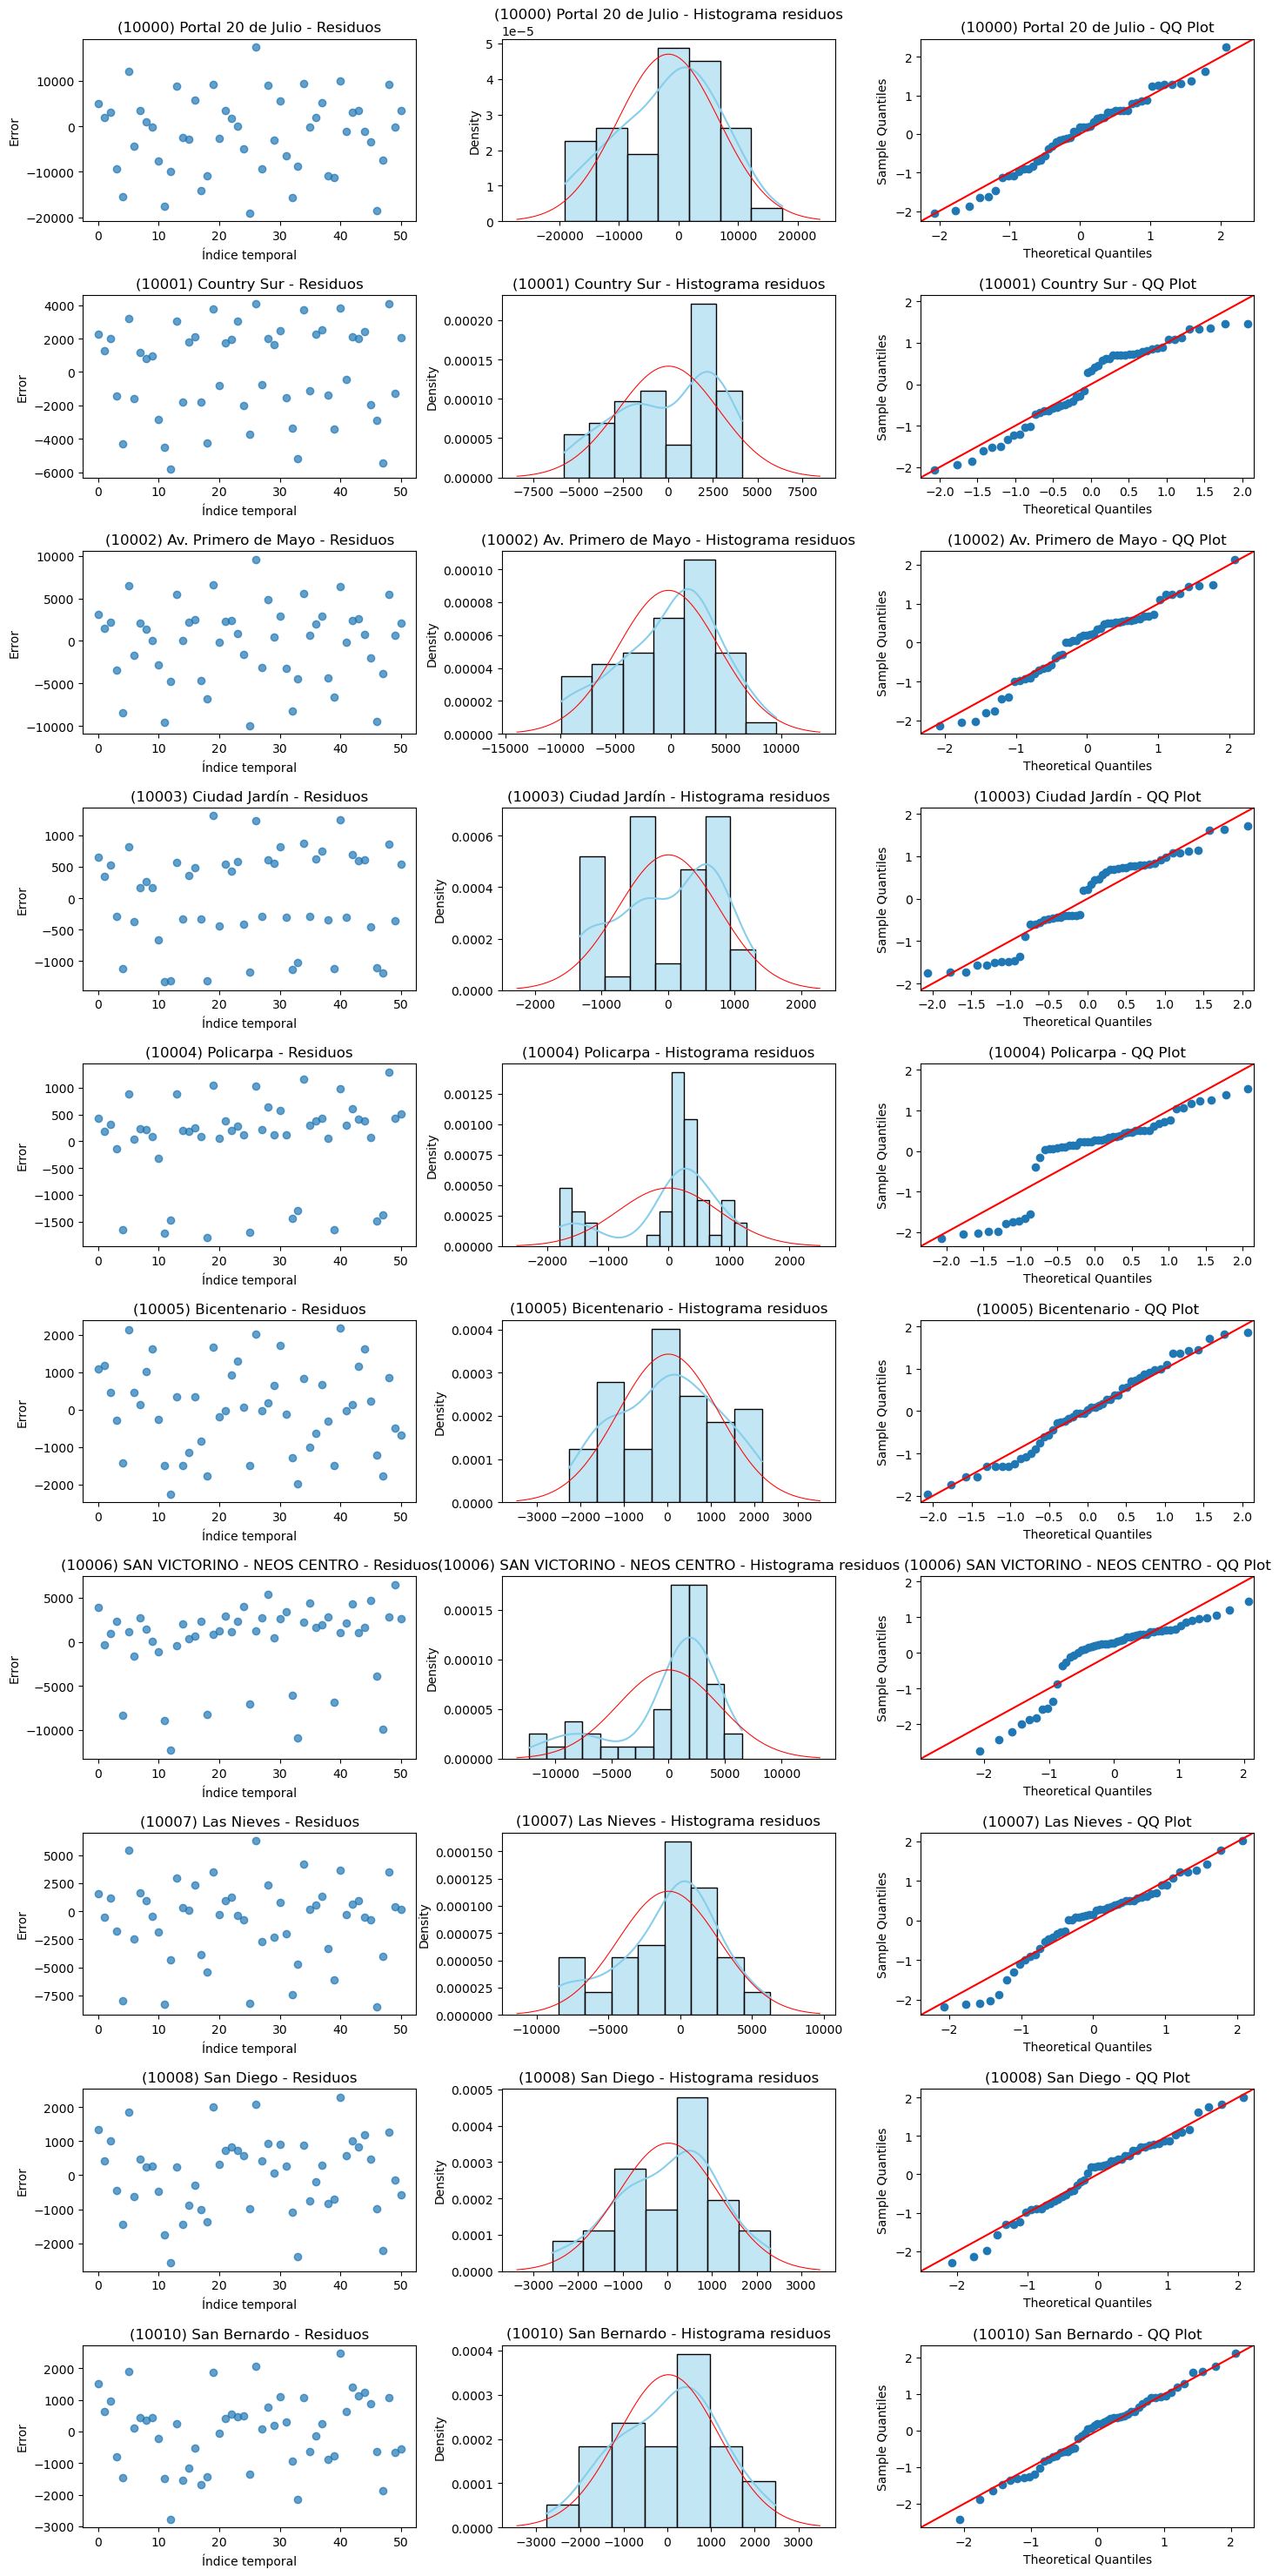

In [123]:
plot_residuals(residuals)